In [ ]:
#########################################
# Step 1. Imports
#########################################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import arch
from arch.univariate import ConstantMean, GARCH, Normal
import keras_tuner as kt
from imblearn.over_sampling import RandomOverSampler
import keras.backend as K
import sys
sys.path.append('../Drafts')
from processing_module import round_hours

In [3]:
import pandas as pd

In [14]:
coins = ['arb', 'avax', 'matic', 'sol', 'btc']
dfs = []
for coin in coins:
    df = pd.read_parquet(f'../Data/do_not_load/{coin}_data.parquet')
    for c in coins:
        if c == coin:
            df[c] = 1
        else:
            df[c] = 0
    dfs.append(df)
data = pd.concat(dfs, axis=0)
data = data.fillna(0)

In [17]:
#########################################
# Step 3. Signal Generation
#########################################
# Compute price difference and its exponential moving average
data['price_diff'] = data['price_close'].diff()

THRESHOLD_MULTIPLIER = 0.5
threshold = data['price_diff'].std()  *0.5

# Define signal function
def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

# Apply signal generation and drop missing values
data['Signal'] = data['price_diff'].apply(lambda x: get_signal(x, threshold))
print("Missing values per column:\n", data.isna().sum())
data.dropna(inplace=True)
print("Missing values per column:\n", data.isna().sum())

Missing values per column:
 active_validators            0
real_reward_rate             0
staked_tokens                0
staking_ratio                0
total_staking_wallets        0
average_gas_limit            0
average_gas_used             0
average_size                 0
unique_number_of_miners      0
average_total_difficulty     0
average_nonce                0
price_close                  0
tech_fib_23                  0
tech_fib_38                  0
tech_fib_50                  0
tech_fib_61                  0
tech_fib_78                  0
tech_bollinger               0
tech_EMAcross                0
tech_RSI                     0
arb                          0
avax                         0
matic                        0
sol                          0
btc                          0
average_height               0
average_total_fees           0
average_total_reward         0
average_mint_reward          0
average_transaction_count    0
average_stripped_size        0
average_ver

In [14]:
#########################################
# Step 4. Splitting data 70%/30%
#########################################
# Prepare features and target arrays
accuracy_train = []
accuracy_test = []

# Use only the lag-adjusted feature columns for training
X = data[all_lag_cols].values
y = data['Signal'].values

# Encode target labels
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

# Define the split index for 70% training data
split_index = int(0.7 * len(X))

# Split the data into training and testing sets
X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get the original labels (not one-hot encoded) for training set
y_train_labels = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

# Create a dictionary of class weights
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Build the model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with class weights
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=0
)

# Evaluate the model on the test set
score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"Train accuracy: {score_2[1]*100:.2f}%")
accuracy_train.append(score_2[1])
print(f"Test accuracy: {scores[1]*100:.2f}%")
accuracy_test.append(scores[1])
best_model = model

Train accuracy: 71.13%
Test accuracy: 70.42%
Train accuracy: 70.69%
Test accuracy: 66.64%
Train accuracy: 71.27%
Test accuracy: 66.14%
Train accuracy: 71.36%
Test accuracy: 69.20%
Train accuracy: 71.98%
Test accuracy: 70.28%
Train accuracy: 70.50%
Test accuracy: 69.16%
Train accuracy: 70.85%
Test accuracy: 69.93%
Train accuracy: 70.90%
Test accuracy: 70.10%
Train accuracy: 70.89%
Test accuracy: 67.58%
Train accuracy: 70.85%
Test accuracy: 69.98%


In [15]:
np.mean(accuracy_train)

0.7104358792304992

In [16]:
np.mean(accuracy_test)

0.6894549787044525

Train accuracy: 71.05%
Test accuracy: 70.17%
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 185us/step


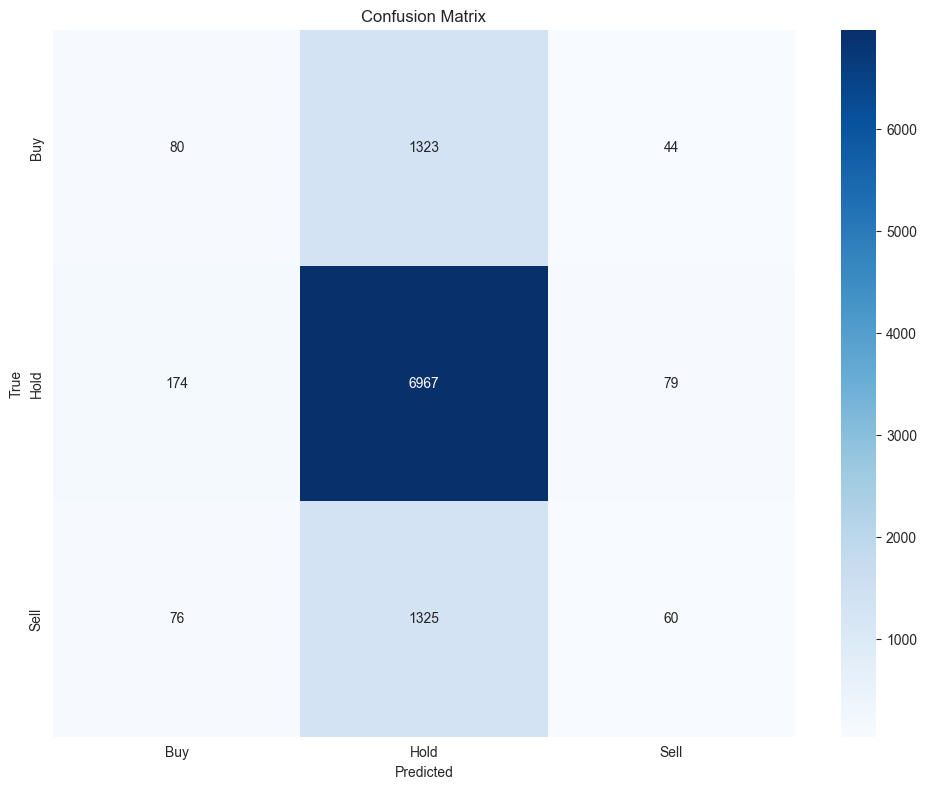


Classification Report:
              precision    recall  f1-score   support

         Buy       0.24      0.06      0.09      1447
        Hold       0.72      0.96      0.83      7220
        Sell       0.33      0.04      0.07      1461

    accuracy                           0.70     10128
   macro avg       0.43      0.35      0.33     10128
weighted avg       0.60      0.70      0.61     10128



In [17]:
#########################################
# Step 4. Splitting data 70%/30%
#########################################
# Prepare features and target arrays

# Use only the lag-adjusted feature columns for training
X = data[all_lag_cols].values
y = data['Signal'].values

# Encode target labels
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

# Define the split index for 70% training data
split_index = int(0.7 * len(X))

# Split the data into training and testing sets
X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get the original labels (not one-hot encoded) for training set
y_train_labels = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

# Create a dictionary of class weights
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Build the model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with class weights
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=0
)

# Evaluate the model on the test set
score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"Train accuracy: {score_2[1]*100:.2f}%")
print(f"Test accuracy: {scores[1]*100:.2f}%")
best_model = model

#########################################
# Confusion Matrix
#########################################
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Get the original class names
class_names = label_encoder.classes_

# Create confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=class_names
))

True \ Predicted
Buy
Hold
Sell
Buy (Actual)
38 (correct)
439 (wrong)
12 (wrong)
Hold (Actual)
216 (wrong)
8851 (correct)
69 (wrong)
Sell (Actual)
37 (wrong)
449 (wrong)
17 (correct


317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step

Trading Performance on Test Data:
Total PnL (percentage): 12.68%
Absolute PnL: $12,682.82
Annualized Sharpe Ratio: 0.1820


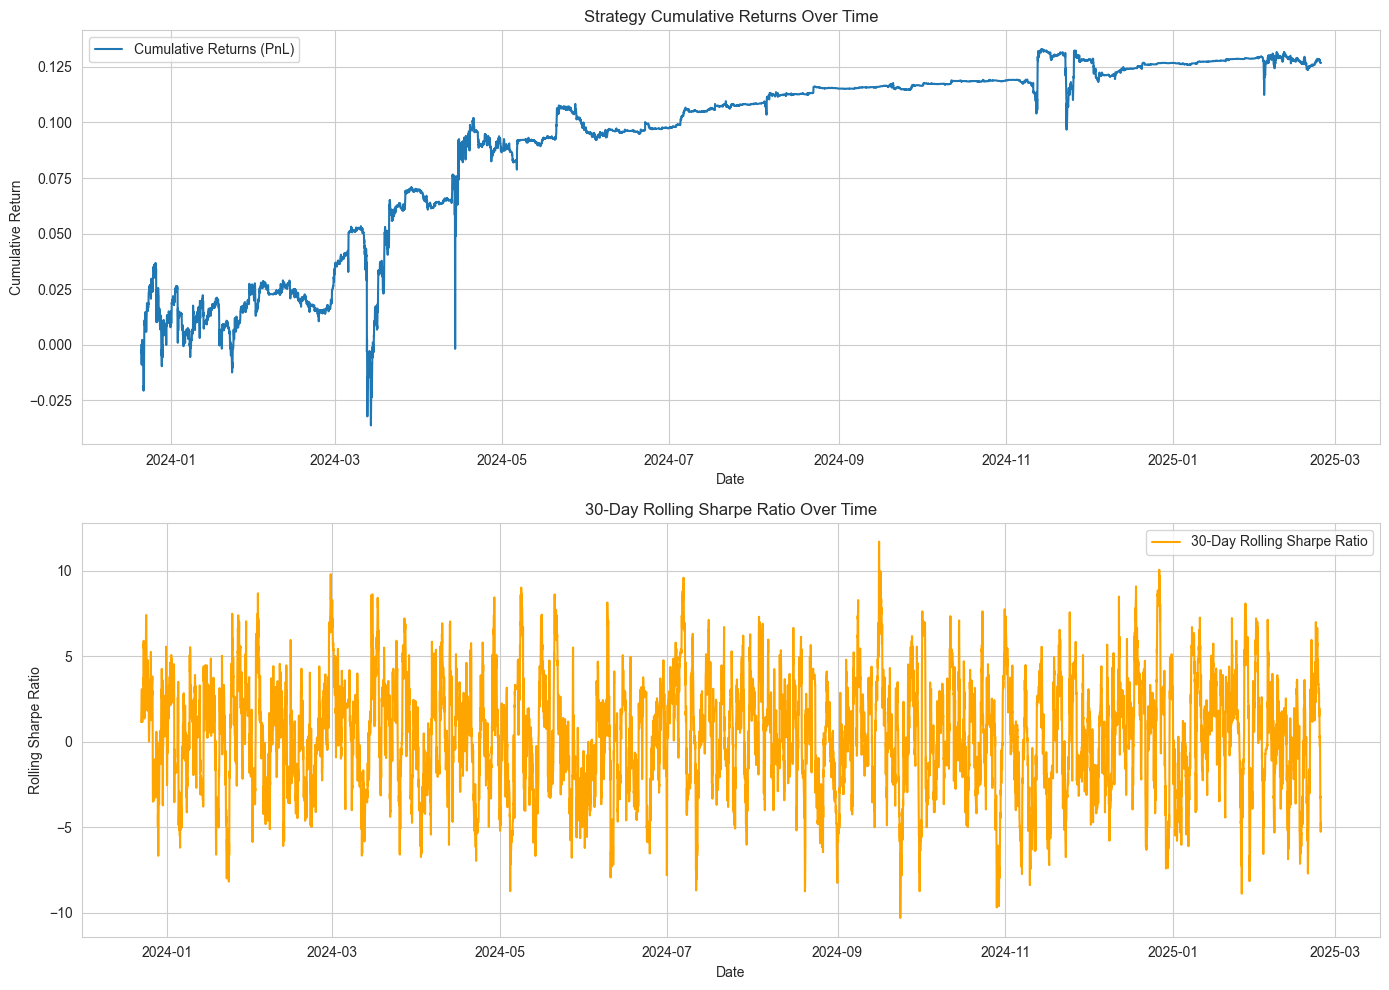

In [20]:
# Define test_data from the combined data split
test_data = data.iloc[split_index:].copy()
test_data['asset_return'] = test_data['price_close'].pct_change()
test_data.dropna(inplace=True)

# Prepare test features and scale them
features_test_aligned = test_data[all_lag_cols].values
X_test_aligned = scaler.transform(features_test_aligned)

# Get prediction probabilities from the trained model
y_pred_test_aligned = best_model.predict(X_test_aligned)

# Define positions as the difference between probability of Buy (assumed index 0)
# and probability of Sell (assumed index 2)
positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]

# Compute the strategy returns: assume positions are applied with a one-period lag
asset_returns_test = test_data['asset_return'].values.astype(np.float32)
strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
strategy_returns_test[0] = 0  # Set the first return to zero

# Calculate cumulative returns and performance metrics
cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
total_pnl_percentage = cumulative_returns_test[-1]
sharpe_ratio_test = (np.mean(strategy_returns_test) / np.std(strategy_returns_test)) * np.sqrt(365)
initial_capital = 100000
absolute_pnl_test = total_pnl_percentage * initial_capital

print("\nTrading Performance on Test Data:")
print("Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
print("Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
print("Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))

# Plot performance metrics
dates = test_data.index
cumulative_returns_series = pd.Series(cumulative_returns_test, index=dates)
returns_series = pd.Series(strategy_returns_test, index=dates)

window = 30
rolling_sharpe = returns_series.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series.index, cumulative_returns_series, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy Cumulative Returns Over Time')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
#########################################
# Step 9. Run the model 10 more times and show each PnL, abs PnL, and annualized Sharpe
#########################################
num_runs = 10
total_pnl_list = []
absolute_pnl_list = []
sharpe_ratio_list = []

# List to store each newly trained model
model_list = []

for run in range(num_runs):
    print(f"\nTraining run {run+1}/{num_runs}")
    
    # Create a new instance of the same model architecture
    model_run = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64),
        LeakyReLU(negative_slope=0.1),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dense(y_cat.shape[1], activation='softmax')
    ])
    model_run.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train the model for 50 epochs
    model_run.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    scores_1 = model_run.evaluate(X_test, y_test, verbose=0)
    scores_2 = model_run.evaluate(X_train, y_train, verbose=0)
    print(f"Train accuracy: {scores_2[1]*100:.2f}%")
    print(f"Test accuracy: {scores_1[1]*100:.2f}%")
    # Store this newly trained model in a list
    model_list.append(model_run)
    
    # Evaluate on the test set
    test_data_run = test_data.copy()
    test_data_run['asset_return'] = test_data_run['price_close'].pct_change()
    strategy_data = test_data_run.dropna().copy()
    
    features_test_aligned = strategy_data[all_lag_cols].values
    X_test_aligned = scaler.transform(features_test_aligned)
    
    y_pred_test_aligned = model_run.predict(X_test_aligned)
    
    # Define positions as the difference between probability of Buy (index 0) and Sell (index 2)
    positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]
    
    asset_returns_test = strategy_data['asset_return'].values.astype(np.float32)
    strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
    strategy_returns_test[0] = 0  # adjust the first value
    
    cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
    total_pnl_percentage = cumulative_returns_test[-1]
    
    # Compute Sharpe ratio; handle zero standard deviation
    std_returns = np.std(strategy_returns_test)
    if std_returns != 0:
        sharpe_ratio_test = (np.mean(strategy_returns_test) / std_returns) * np.sqrt(365)
    else:
        sharpe_ratio_test = 0
        
    initial_capital = 100000
    absolute_pnl_test = total_pnl_percentage * initial_capital
    
    print(f"Run {run+1} Trading Performance:")
    print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
    print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
    print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))
    
    total_pnl_list.append(total_pnl_percentage)
    absolute_pnl_list.append(absolute_pnl_test)
    sharpe_ratio_list.append(sharpe_ratio_test)

# Compute and display average results over all runs
avg_total_pnl = np.mean(total_pnl_list)
avg_absolute_pnl = np.mean(absolute_pnl_list)
avg_sharpe_ratio = np.mean(sharpe_ratio_list)

print("\nAverage Trading Performance over {} runs:".format(num_runs))
print("  Average Total PnL (percentage): {:.2%}".format(avg_total_pnl))
print("  Average Absolute PnL: ${:,.2f}".format(avg_absolute_pnl))
print("  Average Annualized Sharpe Ratio: {:.4f}".format(avg_sharpe_ratio))

# Now you have 10 separate model instances stored in model_list



Training run 1/10
Train accuracy: 75.23%
Test accuracy: 71.29%
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 193us/step
Run 1 Trading Performance:
  Total PnL (percentage): 0.46%
  Absolute PnL: $462.14
  Annualized Sharpe Ratio: 0.2424

Training run 2/10
Train accuracy: 75.05%
Test accuracy: 71.28%
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 197us/step
Run 2 Trading Performance:
  Total PnL (percentage): 3.26%
  Absolute PnL: $3,264.68
  Annualized Sharpe Ratio: 0.4042

Training run 3/10
Train accuracy: 75.07%
Test accuracy: 71.29%
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 192us/step
Run 3 Trading Performance:
  Total PnL (percentage): -0.71%
  Absolute PnL: $-706.84
  Annualized Sharpe Ratio: -0.0767

Training run 4/10
Train accuracy: 74.99%
Test accuracy: 71.29%
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 194us/step
Run 4 Trading Performance:
  Total PnL (percentage): 2.52%
  Absolute PnL: $2,518.76
  Annualized Sharpe Ratio: 0.2094

Training run 5/10
Train accuracy: 75.03%
Test accuracy: 71.29%
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 1

In [21]:
avg_absolute_pnl

974.5645523071289

In [22]:
avg_total_pnl

0.009745645

In [23]:
avg_sharpe_ratio

0.15657358672871363

In [11]:
"""#########################################
# Step 10. Import separate dataset (Arb)
#########################################
# Import Arb dataset (on-chain and price data)
arb1_features = pd.read_parquet('../data/on_chain_data/processed/arb1_chain_processed.parquet')
arb2_features = pd.read_parquet('../data/on_chain_data/processed/arb2_chain_processed.parquet')
arb_prices = pd.read_parquet('../data/price_data/processed/arb_processed_data.parquet')
arb_tech = pd.read_parquet('../data/data_segmented_tech/arb_data.parquet')

common_columns_arb = arb1_features.columns
arb2_features = arb2_features[common_columns_arb]
arb_features = pd.concat([arb1_features, arb2_features], ignore_index=True)

arb_prices['time_close'] = pd.to_datetime(arb_prices['time_close'])
arb_prices.set_index('time_close', inplace=True)
arb_prices.index = arb_prices.index.tz_localize('UTC')

common_length_2 = min(len(arb_prices), len(arb_features))
arb_prices_aligned = arb_prices.iloc[:common_length_2].copy()
arb_features_aligned = arb_features.iloc[:common_length_2].copy()
arb_features_aligned.index = arb_prices_aligned.index

lag_cols_2 = ['average_gas_limit', 'average_gas_used', 'average_size']
arb_features_aligned[lag_cols_2] = arb_features_aligned[lag_cols_2].shift(1)

data_2 = arb_features_aligned.join(arb_prices_aligned[['price_close']], how='inner')

common_length_tech_2 = min(len(arb_tech), len(arb_prices_aligned))
arb_tech_aligned = arb_tech.iloc[:common_length_tech_2].copy()
arb_tech_aligned.index = arb_prices_aligned.index[:common_length_tech_2]

tech_cols_2 = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
arb_tech_renamed = arb_tech_aligned[tech_cols_2].rename(columns=lambda x: "tech_" + x)

data_2 = data_2.join(arb_tech_renamed, how='left')
tech_cols_renamed_2 = ["tech_" + col for col in tech_cols_2]
feature_cols_2 = lag_cols_2 + tech_cols_renamed_2"""

'#########################################\n# Step 10. Import separate dataset (Arb)\n#########################################\n# Import Arb dataset (on-chain and price data)\narb1_features = pd.read_parquet(\'../data/on_chain_data/processed/arb1_chain_processed.parquet\')\narb2_features = pd.read_parquet(\'../data/on_chain_data/processed/arb2_chain_processed.parquet\')\narb_prices = pd.read_parquet(\'../data/price_data/processed/arb_processed_data.parquet\')\narb_tech = pd.read_parquet(\'../data/data_segmented_tech/arb_data.parquet\')\n\ncommon_columns_arb = arb1_features.columns\narb2_features = arb2_features[common_columns_arb]\narb_features = pd.concat([arb1_features, arb2_features], ignore_index=True)\n\narb_prices[\'time_close\'] = pd.to_datetime(arb_prices[\'time_close\'])\narb_prices.set_index(\'time_close\', inplace=True)\narb_prices.index = arb_prices.index.tz_localize(\'UTC\')\n\ncommon_length_2 = min(len(arb_prices), len(arb_features))\narb_prices_aligned = arb_prices.iloc

In [12]:
"""#########################################
# Step 11. Use Arb as an out-of-sample test
#########################################
# Generate signals on Arb data
data_2['price_diff'] = data_2['price_close'].diff()
data_2['ewma_diff'] = data_2['price_diff'].ewm(span=6, adjust=False).mean()
threshold_2 = data_2['price_diff'].std()*0.5

def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

data_2['Signal'] = data_2['ewma_diff'].apply(lambda x: get_signal(x, threshold_2))
data_2 = data_2.dropna()
data_2 = data_2.sort_index()

# Ensure that all feature columns exist in Arb data
missing_features = [col for col in feature_cols if col not in data_2.columns]
if missing_features:
    print("Missing features in Arb data:", missing_features)
    for col in missing_features:
        data_2[col] = 0
data_2 = data_2.reindex(columns=list(set(feature_cols).union(data_2.columns)), fill_value=0)

# Prepare Arb data for evaluation
features_data2 = data_2[feature_cols].values
labels_data2 = data_2['Signal'].values
integer_encoded_data2 = label_encoder.transform(labels_data2)
y_data2 = to_categorical(integer_encoded_data2)
X_data2 = scaler.transform(features_data2)

# Evaluate classification performance on Arb data
loss_data2, accuracy_data2 = best_model.evaluate(X_data2, y_data2, verbose=0)
print("Out-of-Sample Classification Performance:")
print("  Test Loss: {:.4f}".format(loss_data2))
print("  Test Accuracy: {:.4f}".format(accuracy_data2))

# Compute trading performance on Arb data
data_2['asset_return'] = data_2['price_close'].pct_change()
strategy_data2 = data_2.dropna().copy()
features_data2_aligned = strategy_data2[feature_cols].values
X_data2_aligned = scaler.transform(features_data2_aligned)
y_pred_data2 = best_model.predict(X_data2_aligned)
positions_data2 = y_pred_data2[:, 0] - y_pred_data2[:, 2]

asset_returns_data2 = strategy_data2['asset_return'].values.astype(np.float32)
strategy_returns_data2 = np.roll(positions_data2, shift=1) * asset_returns_data2
strategy_returns_data2[0] = 0

cumulative_returns_data2 = np.cumprod(1 + strategy_returns_data2) - 1
total_pnl_percentage_data2 = cumulative_returns_data2[-1]
absolute_pnl_data2 = total_pnl_percentage_data2 * initial_capital
if np.std(strategy_returns_data2) != 0:
    sharpe_ratio_data2 = (np.mean(strategy_returns_data2) / np.std(strategy_returns_data2)) * np.sqrt(365)
else:
    sharpe_ratio_data2 = 0

print("\nOut-of-Sample Trading Performance:")
print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage_data2))
print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_data2))
print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_data2))

# Plot Arb performance metrics
dates = strategy_data2.index
cumulative_returns_series_data2 = pd.Series(cumulative_returns_data2, index=dates)
returns_series_data2 = pd.Series(strategy_returns_data2, index=dates)
window = 5
rolling_sharpe_data2 = returns_series_data2.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series_data2.index, cumulative_returns_series_data2, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Out-of-Sample Strategy Cumulative Returns')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe_data2.index, rolling_sharpe_data2, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
"""

'#########################################\n# Step 11. Use Arb as an out-of-sample test\n#########################################\n# Generate signals on Arb data\ndata_2[\'price_diff\'] = data_2[\'price_close\'].diff()\ndata_2[\'ewma_diff\'] = data_2[\'price_diff\'].ewm(span=6, adjust=False).mean()\nthreshold_2 = data_2[\'price_diff\'].std()*0.5\n\ndef get_signal(diff, threshold):\n    if diff > threshold:\n        return \'Buy\'\n    elif diff < -threshold:\n        return \'Sell\'\n    else:\n        return \'Hold\'\n\ndata_2[\'Signal\'] = data_2[\'ewma_diff\'].apply(lambda x: get_signal(x, threshold_2))\ndata_2 = data_2.dropna()\ndata_2 = data_2.sort_index()\n\n# Ensure that all feature columns exist in Arb data\nmissing_features = [col for col in feature_cols if col not in data_2.columns]\nif missing_features:\n    print("Missing features in Arb data:", missing_features)\n    for col in missing_features:\n        data_2[col] = 0\ndata_2 = data_2.reindex(columns=list(set(feature_co

In [ ]:
def run_crypto_model(crypto_name, num_runs=10, threshold_multiplier = 0.5):
    """
    Run the cryptocurrency trading model multiple times and store performance metrics.

    Parameters:
    -----------
    crypto_name : str
        Cryptocurrency ticker symbol (lowercase, e.g., 'aval', 'eth', 'btc')
    num_runs : int, default=10
        Number of times to run the model

    Returns:
    --------
    dict
        Dictionary containing performance metrics:
        - 'avg_total_pnl': Average total profit and loss as percentage
        - 'avg_absolute_pnl': Average absolute profit and loss in dollars
        - 'avg_sharpe_ratio': Average annualized Sharpe ratio
        - 'crypto': Cryptocurrency name
        - 'num_runs': Number of runs performed
        - 'runs_data': List of dictionaries with individual run metrics
    """
    import numpy as np
    import pandas as pd
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Input, LeakyReLU
    from tensorflow.keras.utils import to_categorical
    from sklearn.preprocessing import StandardScaler, LabelEncoder

    # Store results for each run
    results = {
        'crypto': crypto_name,
        'num_runs': num_runs,
        'runs_data': [],
        'avg_total_pnl': None,
        'avg_absolute_pnl': None,
        'avg_sharpe_ratio': None
    }

    # Prepare data for the specified cryptocurrency
    data = prep_data(crypto=crypto_name)

    # Add additional technical indicators
    data = add_more_indicators(data)

    # Define features for model
    tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
    lag_cols = [
        'average_gas_limit', 'average_gas_used', 'average_size',
        'average_total_difficulty', 'active_validators', 'real_reward_rate',
        'staked_tokens', 'staking_ratio', 'total_staking_wallets'
    ]
    tech_cols_renamed = ["tech_" + col for col in tech_cols]
    all_lag_cols = lag_cols + tech_cols_renamed

    # ==================================================
    # Apply lag to all feature columns
    # ==================================================
    data[all_lag_cols] = data[all_lag_cols].shift(1)

    # Generate forward-looking target
    data['future_price_diff'] = data['price_close'].shift(-1) - data['price_close']

    # Define signal function with threshold
    threshold_multiplier = 0.5  # Can be adjusted as needed
    threshold = data['future_price_diff'].std() * threshold_multiplier

    def get_signal(diff, threshold):
        if diff > threshold:
            return 'Buy'
        elif diff < -threshold:
            return 'Sell'
        else:
            return 'Hold'

    # Generate signals
    data['Signal'] = data['future_price_diff'].apply(lambda x: get_signal(x, threshold))

    # Clean data
    data.sort_index(inplace=True)
    data.dropna(inplace=True)

    # Define features and target
    X = data[all_lag_cols].values
    y = data['Signal'].values

    # Encode target labels
    label_encoder = LabelEncoder()
    integer_encoded = label_encoder.fit_transform(y)
    y_cat = to_categorical(integer_encoded)

    # Split the data (70% train, 30% test)
    split_index = int(0.7 * len(X))
    X_train = X[:split_index]
    y_train = y_cat[:split_index]
    X_test = X[split_index:]
    y_test = y_cat[split_index:]

    # Scale features
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    # Prepare test data for performance evaluation
    test_data = data.iloc[split_index:].copy()
    test_data['asset_return'] = test_data['price_close'].pct_change()
    test_data = test_data.dropna()

    # Lists to store performance metrics
    total_pnl_list = []
    absolute_pnl_list = []
    sharpe_ratio_list = []

    # Run model multiple times
    for run in range(num_runs):
        run_results = {
            'run_num': run + 1,
            'total_pnl': None,
            'absolute_pnl': None,
            'sharpe_ratio': None,
            'train_accuracy': None,
            'test_accuracy': None
        }

        # Create model
        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(64),
            LeakyReLU(negative_slope=0.1),
            Dense(32),
            LeakyReLU(negative_slope=0.1),
            Dense(y_cat.shape[1], activation='softmax')
        ])
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        # Train model
        model.fit(
            X_train, y_train,
            epochs=50,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        # Evaluate model
        train_scores = model.evaluate(X_train, y_train, verbose=0)
        test_scores = model.evaluate(X_test, y_test, verbose=0)
        run_results['train_accuracy'] = train_scores[1]
        run_results['test_accuracy'] = test_scores[1]

        # Get trading performance
        features_test = test_data[all_lag_cols].values
        X_test_scaled = scaler.transform(features_test)

        # Get prediction probabilities
        y_pred = model.predict(X_test_scaled)

        # Define positions (Buy probability - Sell probability)
        positions = y_pred[:, 0] - y_pred[:, 2]

        # Calculate strategy returns
        asset_returns = test_data['asset_return'].values.astype(np.float32)
        strategy_returns = np.roll(positions, shift=1) * asset_returns
        strategy_returns[0] = 0  # Set first value to zero

        # Calculate performance metrics
        cumulative_returns = np.cumprod(1 + strategy_returns) - 1
        total_pnl = cumulative_returns[-1]

        # Compute Sharpe ratio (handle zero standard deviation)
        std_returns = np.std(strategy_returns)
        if std_returns != 0:
            sharpe_ratio = (np.mean(strategy_returns) / std_returns) * np.sqrt(365)
        else:
            sharpe_ratio = 0

        # Calculate absolute P&L
        initial_capital = 100000
        absolute_pnl = total_pnl * initial_capital

        # Store run results
        run_results['total_pnl'] = total_pnl
        run_results['absolute_pnl'] = absolute_pnl
        run_results['sharpe_ratio'] = sharpe_ratio

        results['runs_data'].append(run_results)

        # Add to metric lists
        total_pnl_list.append(total_pnl)
        absolute_pnl_list.append(absolute_pnl)
        sharpe_ratio_list.append(sharpe_ratio)

    # Calculate average metrics
    results['avg_total_pnl'] = np.mean(total_pnl_list)
    results['avg_absolute_pnl'] = np.mean(absolute_pnl_list)
    results['avg_sharpe_ratio'] = np.mean(sharpe_ratio_list)

    # Also include standard deviation for each metric
    results['std_total_pnl'] = np.std(total_pnl_list)
    results['std_absolute_pnl'] = np.std(absolute_pnl_list)
    results['std_sharpe_ratio'] = np.std(sharpe_ratio_list)

    # Calculate median values for more robust central tendency
    results['median_total_pnl'] = np.median(total_pnl_list)
    results['median_absolute_pnl'] = np.median(absolute_pnl_list)
    results['median_sharpe_ratio'] = np.median(sharpe_ratio_list)

    # Print summary statistics
    print(f"\nResults for {crypto_name} over {num_runs} runs:")
    print(f"Average Total PnL: {results['avg_total_pnl']:.2%}")
    print(f"Average Absolute PnL: ${results['avg_absolute_pnl']:,.2f}")
    print(f"Average Sharpe Ratio: {results['avg_sharpe_ratio']:.4f}")

    return results